In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Day18_19_student_habits_performance.csv")

print("Shape:", df.shape)
df.head()

Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance.csv
Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
id_col = "student_id"
target = "exam_score"

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != id_col]

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
parental_education_level,91,9.1


In [6]:
df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [7]:
df[categorical_cols].describe().T


,count,unique,top,freq
gender,1000,3,Female,481
part_time_job,1000,2,No,785
diet_quality,1000,3,Fair,437
parental_education_level,909,3,High School,392
internet_quality,1000,3,Good,447
extracurricular_participation,1000,2,No,682


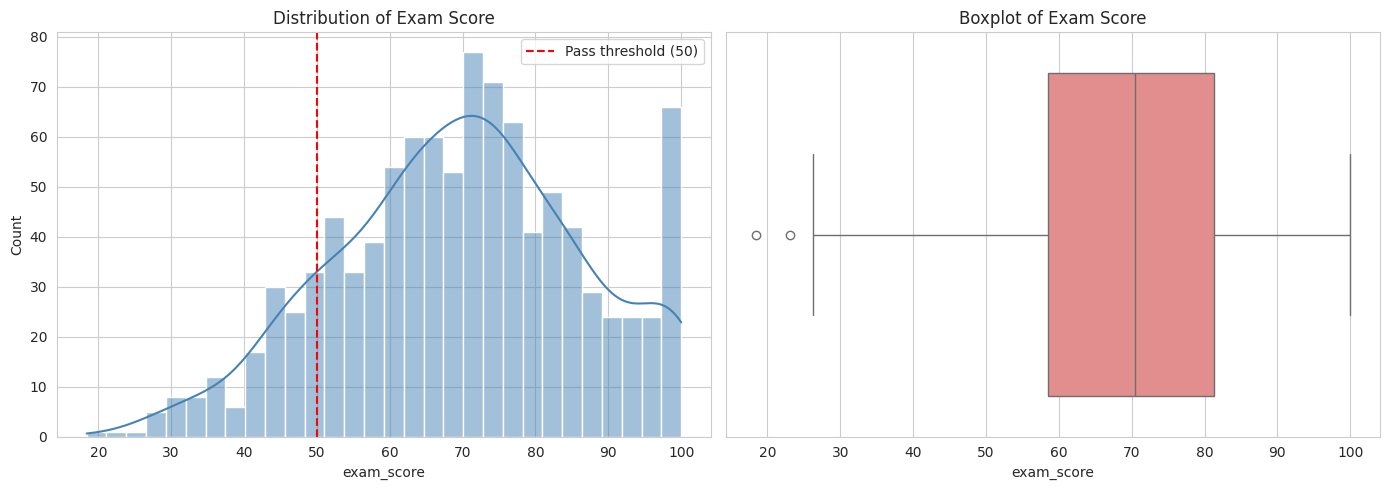

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["exam_score"], kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Exam Score")
axes[0].axvline(50, color="red", linestyle="--", label="Pass threshold (50)")
axes[0].legend()

sns.boxplot(x=df["exam_score"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot of Exam Score")

plt.tight_layout()
plt.show()

print(df["exam_score"].describe())


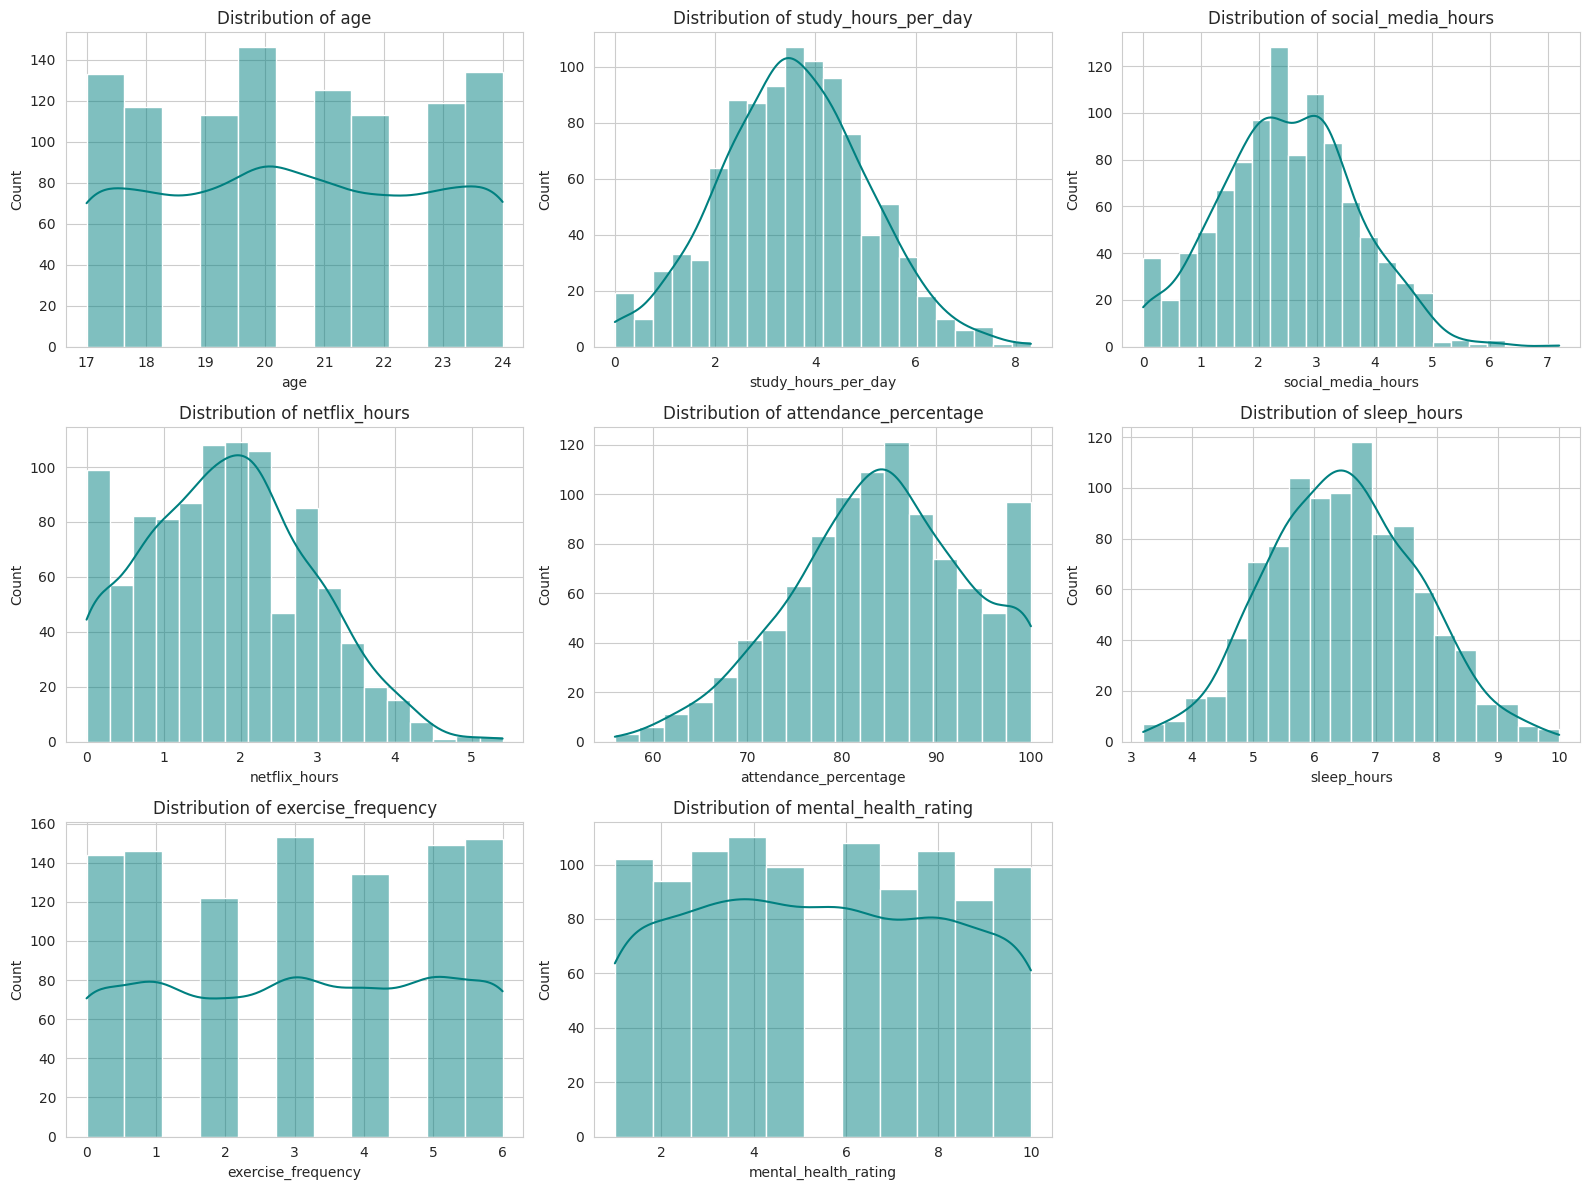

In [9]:
num_features = [c for c in numerical_cols if c not in [target]]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


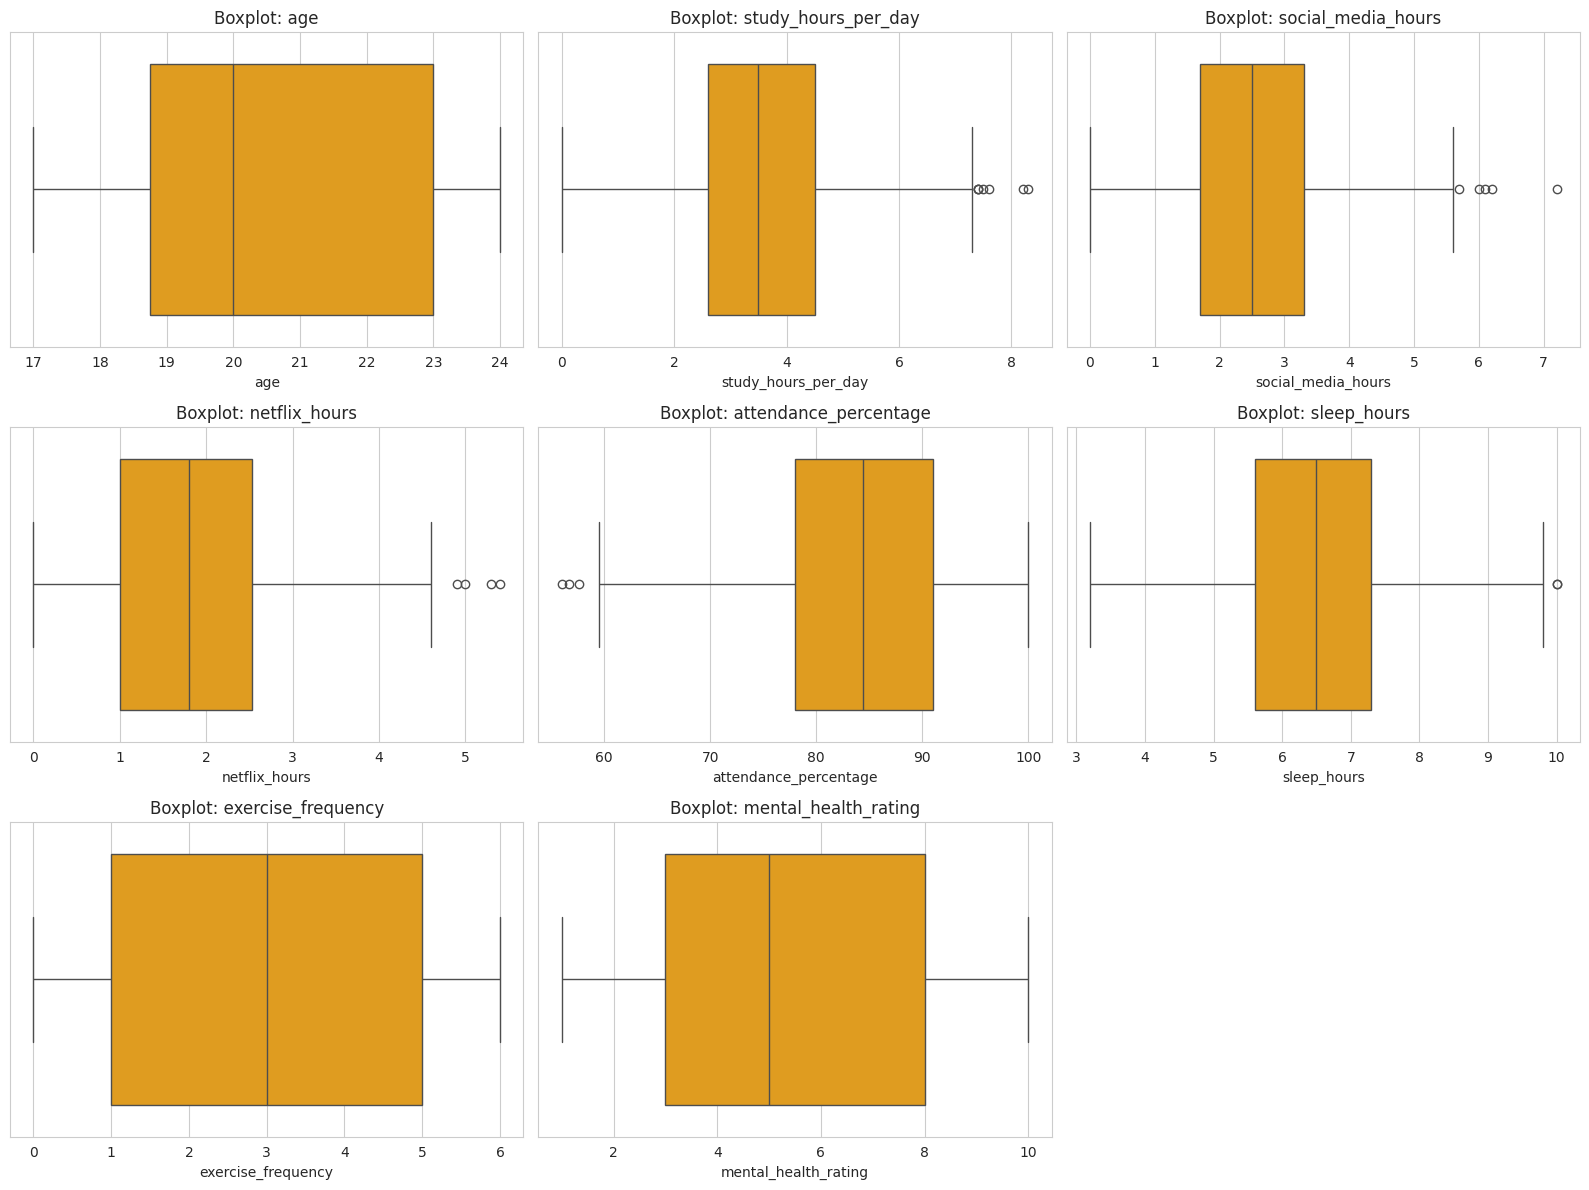

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(x=df[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot: {col}")
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [11]:
# Quantify outliers using the IQR method
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {col: iqr_outlier_count(df[col]) for col in num_features}
pd.Series(outlier_counts, name="outlier_count").sort_values(ascending=False)


,outlier_count
study_hours_per_day,7
social_media_hours,5
netflix_hours,4
attendance_percentage,3
sleep_hours,2
age,0
exercise_frequency,0
mental_health_rating,0


/tmp/ipykernel_1088/963397687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_1088/963397687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_1088/963397687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_1088/963397687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

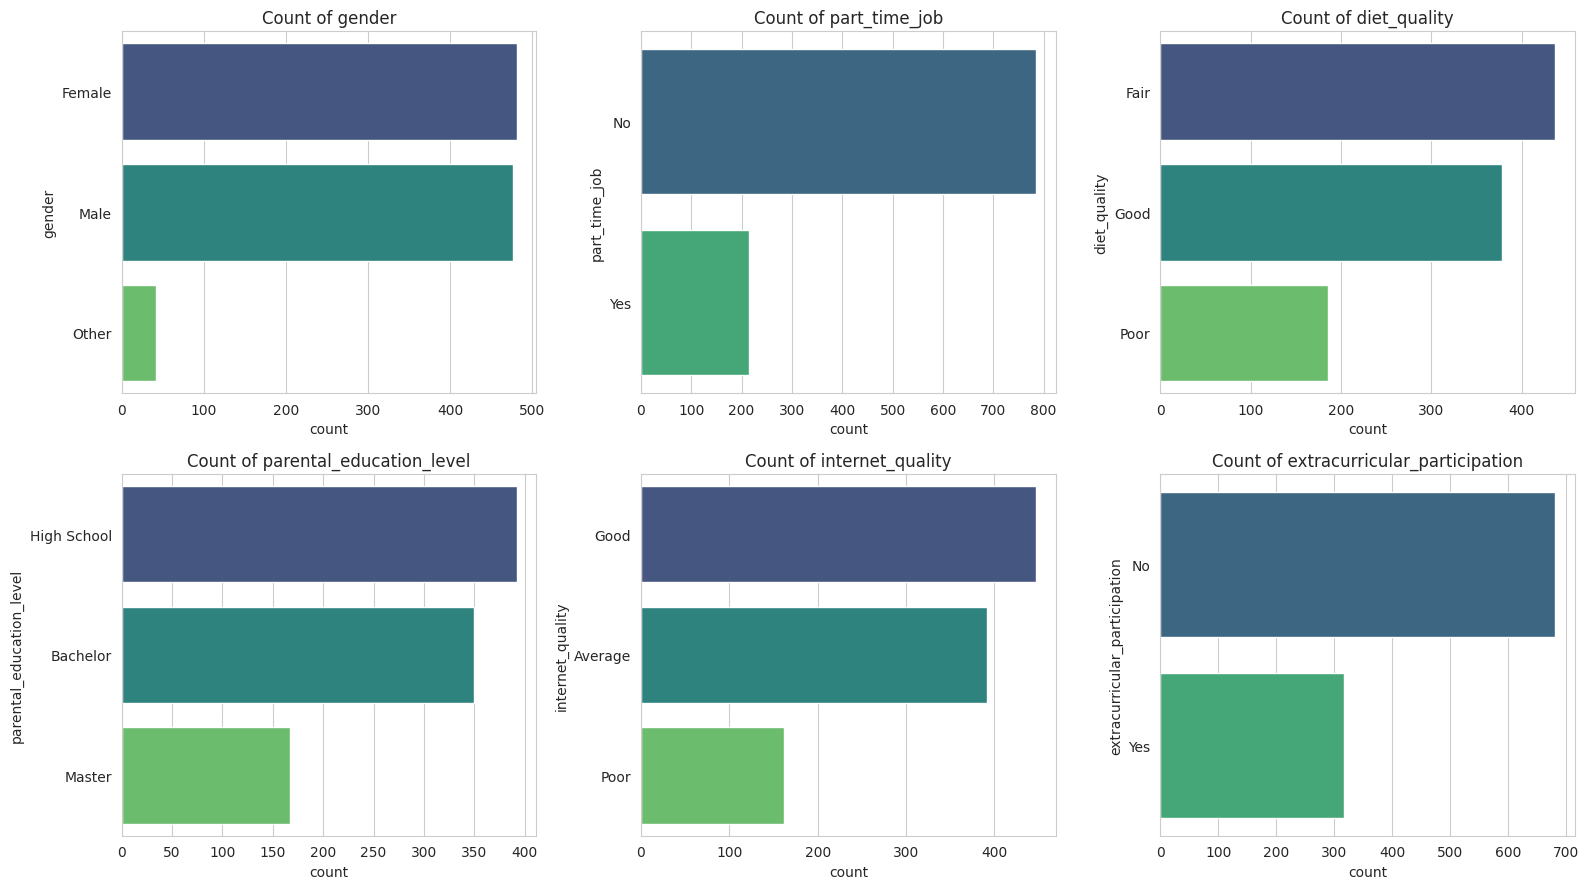

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Count of {col}")
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


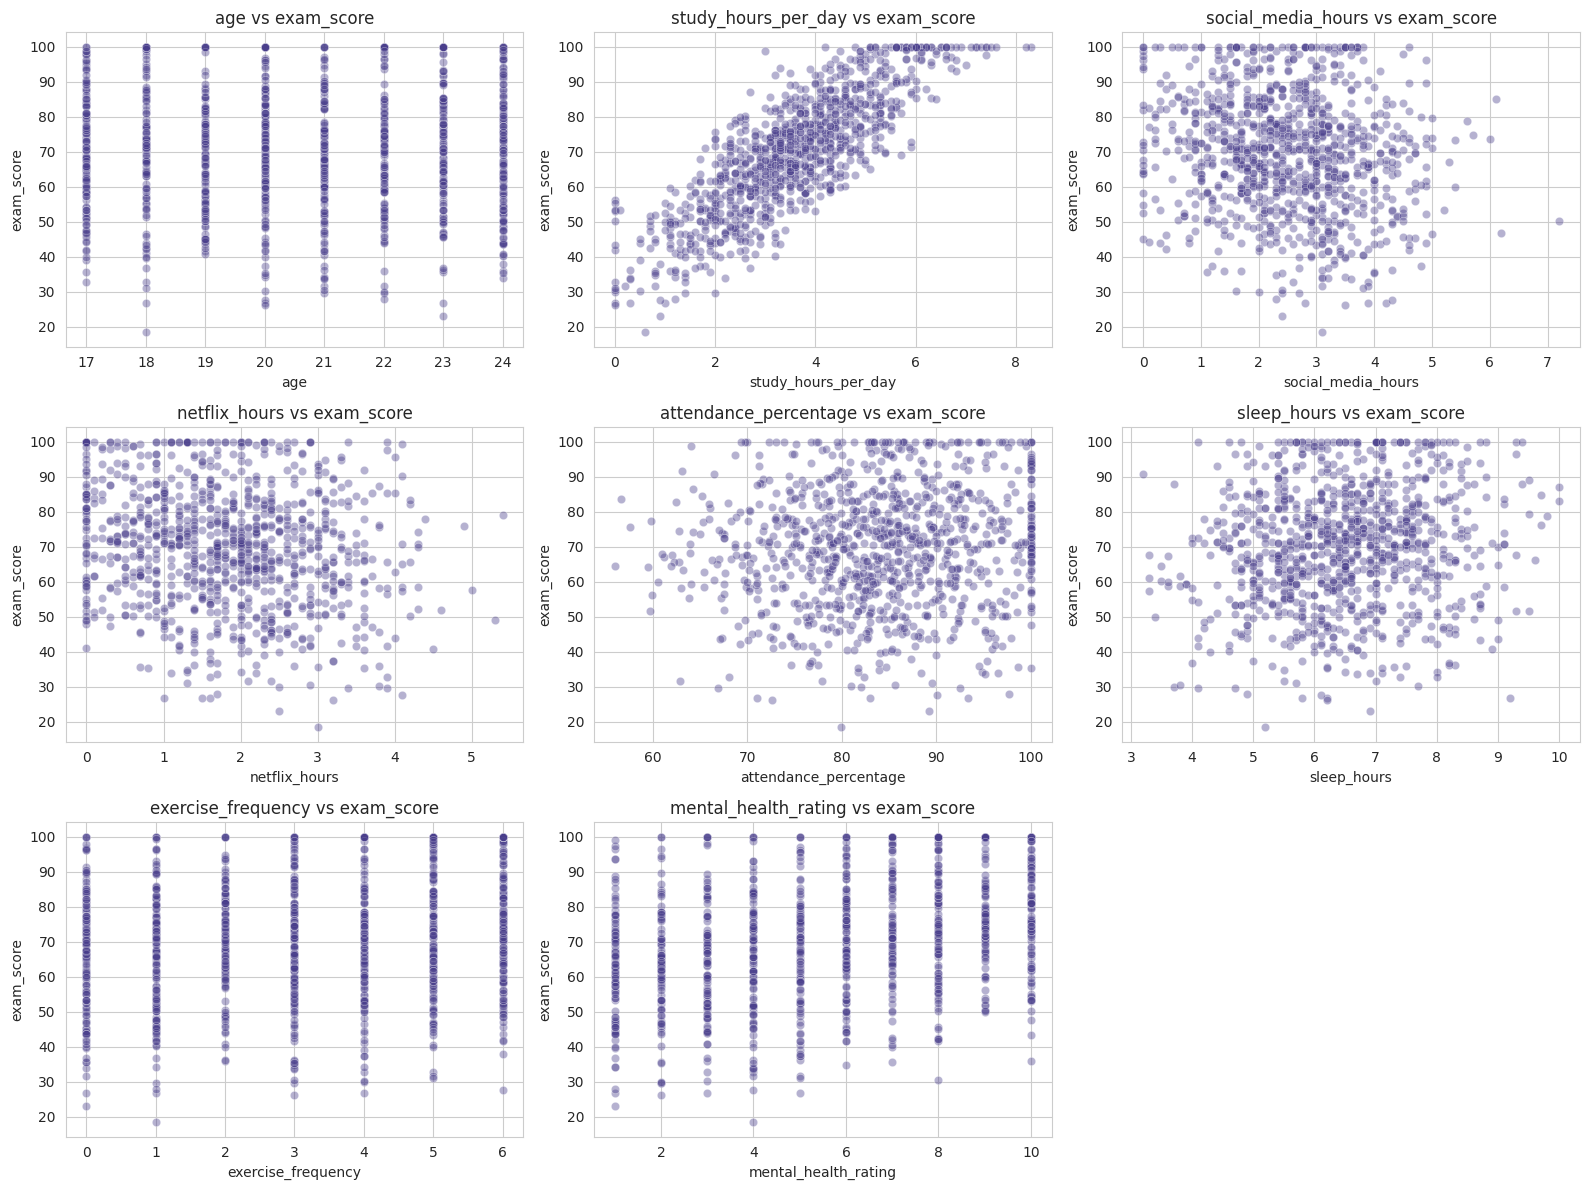

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.scatterplot(x=df[col], y=df[target], ax=axes[i], alpha=0.4, color="darkslateblue")
    axes[i].set_title(f"{col} vs exam_score")
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


/tmp/ipykernel_1088/3772799534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_1088/3772799534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_1088/3772799534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_1088/3772799534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

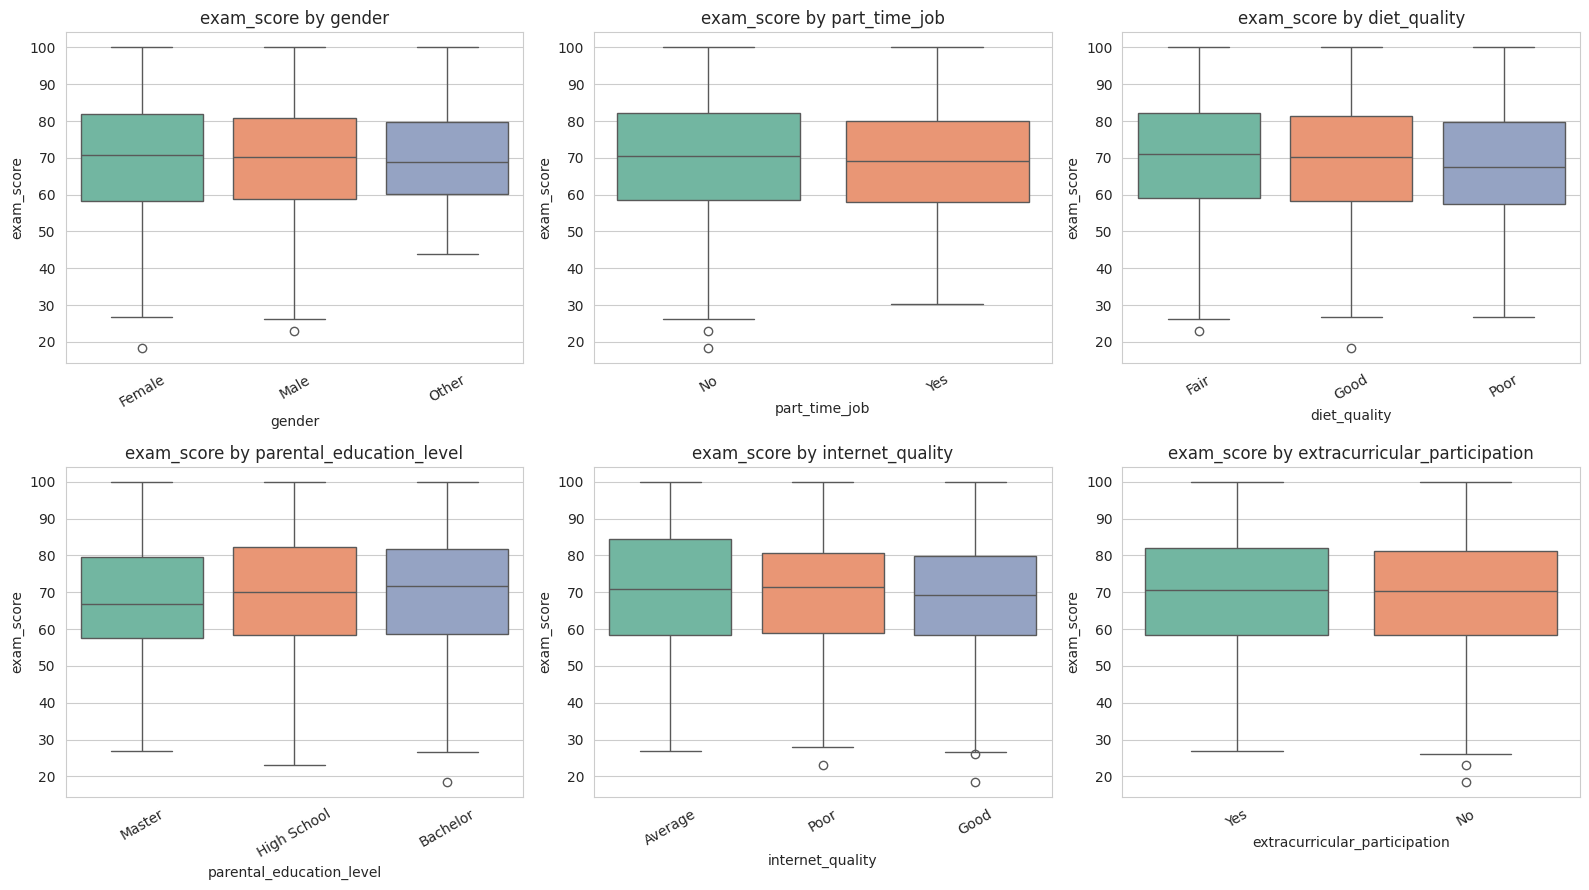

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y=target, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"exam_score by {col}")
    axes[i].tick_params(axis="x", rotation=30)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

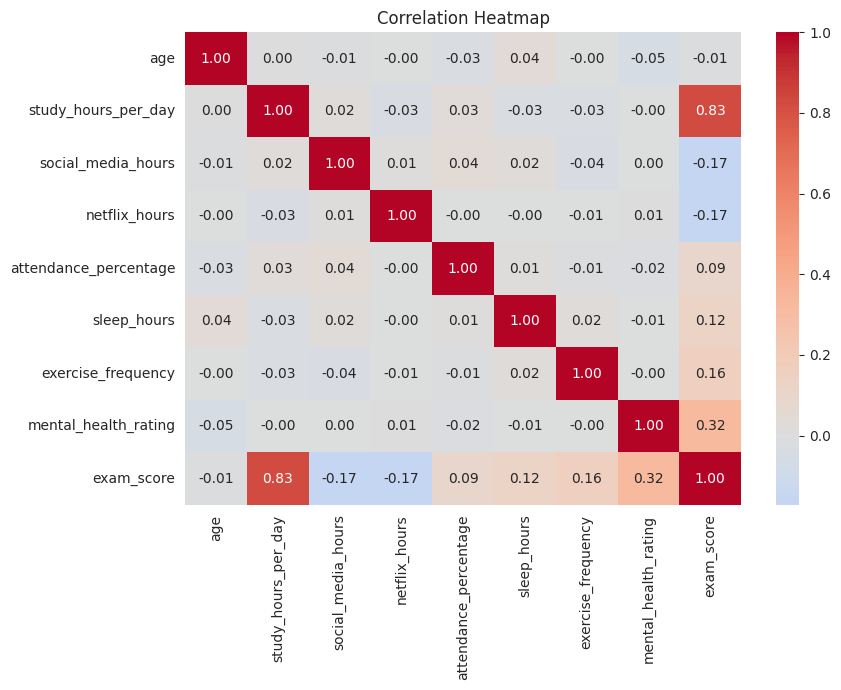

Correlation with exam_score (sorted):
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [15]:
corr = df[num_features + [target]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with exam_score (sorted):")
print(corr[target].sort_values(ascending=False))


In [16]:
feature_cols = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency",
    "mental_health_rating", "age",
    "gender", "part_time_job", "diet_quality",
    "parental_education_level", "internet_quality", "extracurricular_participation"
]

X = df[feature_cols].copy()
y_reg = df["exam_score"].copy()

# Fill missing categorical values with an explicit "Unknown" category
X["parental_education_level"] = X["parental_education_level"].fillna("Unknown")

numeric_features = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency",
    "mental_health_rating", "age"
]
categorical_features = [
    "gender", "part_time_job", "diet_quality",
    "parental_education_level", "internet_quality", "extracurricular_participation"
]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

X.head()


,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,age,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
0,0.0,1.2,1.1,85.0,8.0,6,8,23,Female,No,Fair,Master,Average,Yes
1,6.9,2.8,2.3,97.3,4.6,6,8,20,Female,No,Good,High School,Average,No
2,1.4,3.1,1.3,94.8,8.0,1,1,21,Male,No,Poor,High School,Poor,No
3,1.0,3.9,1.0,71.0,9.2,4,1,23,Female,No,Poor,Master,Good,Yes
4,5.0,4.4,0.5,90.9,4.9,3,1,19,Female,No,Fair,Master,Good,No


In [17]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (800, 14)
Test shape: (200, 14)


In [18]:
reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

reg_pipeline.fit(X_train, y_train_reg)

y_train_pred = reg_pipeline.predict(X_train)
y_test_pred = reg_pipeline.predict(X_test)


In [19]:
def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R^2  : {r2:.3f}\n")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_train_reg, y_train_pred, "Training Set")
test_metrics  = regression_report(y_test_reg,  y_test_pred,  "Test Set")


--- Training Set ---
MAE  : 4.212
MSE  : 28.555
RMSE : 5.344
R^2  : 0.902

--- Test Set ---
MAE  : 4.189
MSE  : 26.476
RMSE : 5.146
R^2  : 0.897



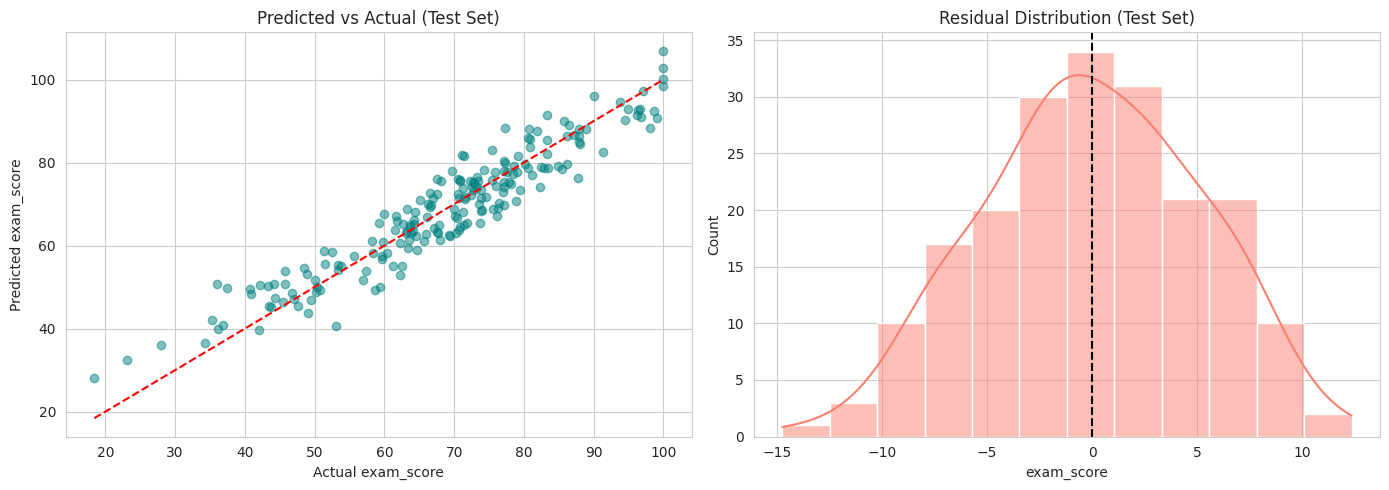

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_test_pred, alpha=0.5, color="teal")
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], "r--")
axes[0].set_xlabel("Actual exam_score")
axes[0].set_ylabel("Predicted exam_score")
axes[0].set_title("Predicted vs Actual (Test Set)")

residuals = y_test_reg - y_test_pred
sns.histplot(residuals, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Residual Distribution (Test Set)")
axes[1].axvline(0, color="black", linestyle="--")

plt.tight_layout()
plt.show()


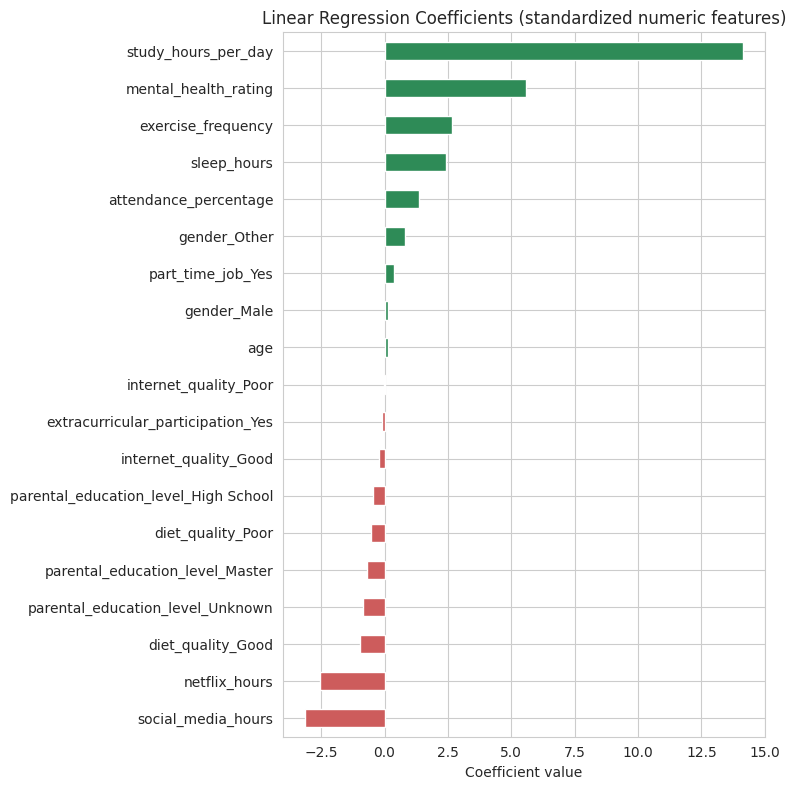

,0
study_hours_per_day,14.144736
mental_health_rating,5.564302
exercise_frequency,2.656236
sleep_hours,2.421586
attendance_percentage,1.359685
gender_Other,0.810709
part_time_job_Yes,0.370921
gender_Male,0.134296
age,0.120528
internet_quality_Poor,-0.027938


In [21]:
ohe_cols = reg_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

coefs = pd.Series(
    reg_pipeline.named_steps["model"].coef_, index=all_feature_names
).sort_values()

plt.figure(figsize=(8, 8))
coefs.plot(kind="barh", color=np.where(coefs > 0, "seagreen", "indianred"))
plt.title("Linear Regression Coefficients (standardized numeric features)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)


In [22]:
y_class = (df["exam_score"] >= 50).astype(int)
print(y_class.value_counts())
print("\nClass balance:")
print(y_class.value_counts(normalize=True).round(3))


exam_score
1    869
0    131
Name: count, dtype: int64

Class balance:
exam_score
1    0.869
0    0.131
Name: proportion, dtype: float64


In [23]:
X_train_c, X_test_c, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf_pipeline.fit(X_train_c, y_train_cls)

y_train_pred_cls = clf_pipeline.predict(X_train_c)
y_test_pred_cls  = clf_pipeline.predict(X_test_c)


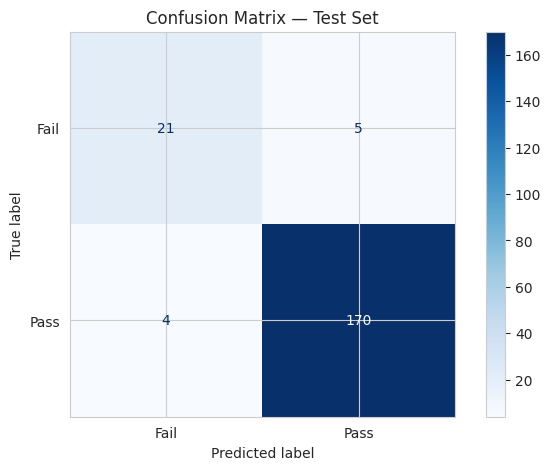

In [24]:
cm = confusion_matrix(y_test_cls, y_test_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()


In [25]:
def classification_report_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-score  : {f1:.3f}\n")
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

train_cls_metrics = classification_report_metrics(y_train_cls, y_train_pred_cls, "Training Set")
test_cls_metrics  = classification_report_metrics(y_test_cls,  y_test_pred_cls,  "Test Set")

print(classification_report(y_test_cls, y_test_pred_cls, target_names=["Fail", "Pass"]))


--- Training Set ---
Accuracy  : 0.959
Precision : 0.970
Recall    : 0.983
F1-score  : 0.976

--- Test Set ---
Accuracy  : 0.955
Precision : 0.971
Recall    : 0.977
F1-score  : 0.974

              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



In [26]:
reg_compare = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).T
reg_compare


,MAE,MSE,RMSE,R2
Train,4.212312,28.554912,5.343680,0.902146
Test,4.189311,26.476236,5.145506,0.896750


In [27]:
cls_compare = pd.DataFrame({"Train": train_cls_metrics, "Test": test_cls_metrics}).T
cls_compare


,Accuracy,Precision,Recall,F1
Train,0.95875,0.970170,0.982734,0.976412
Test,0.95500,0.971429,0.977011,0.974212
